Pesos aleatorios iniciales compartidos: w0=-0.1255, w1=0.4507, w2=0.2320



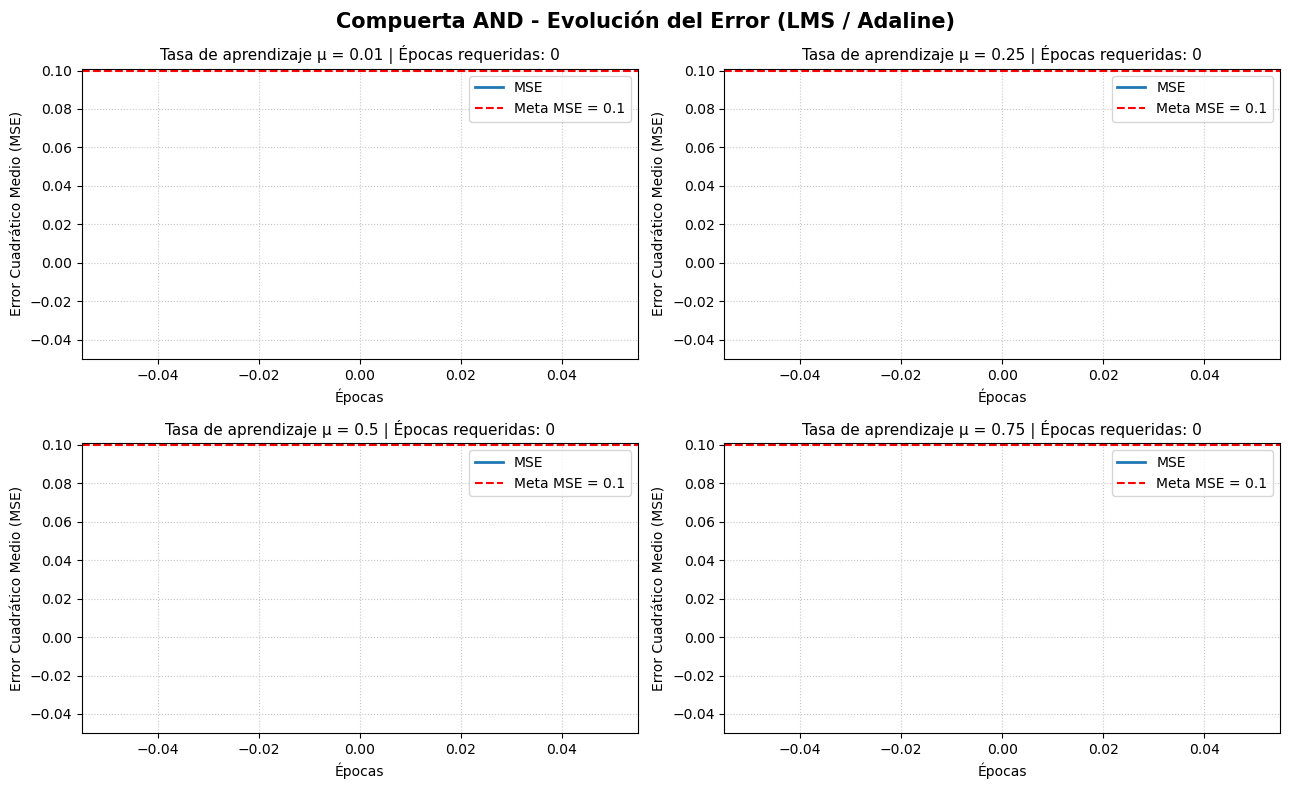

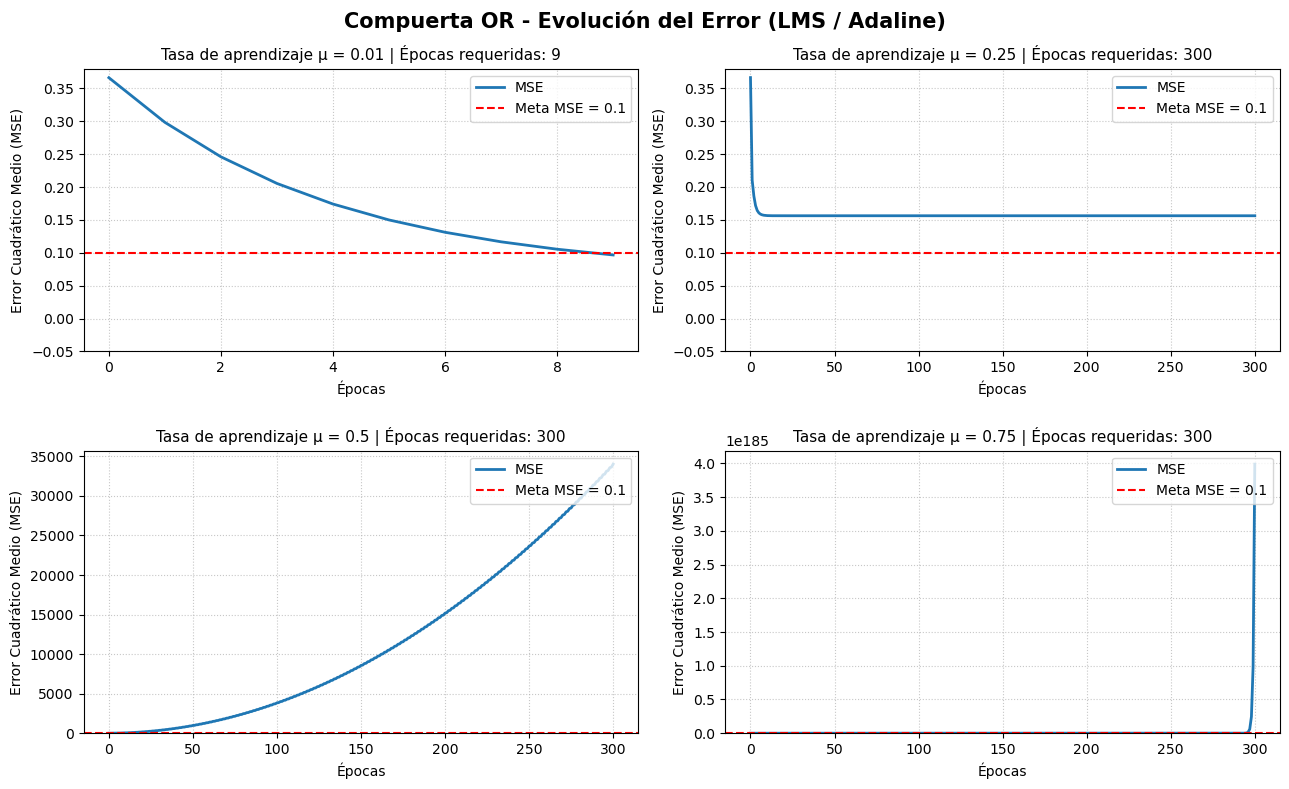

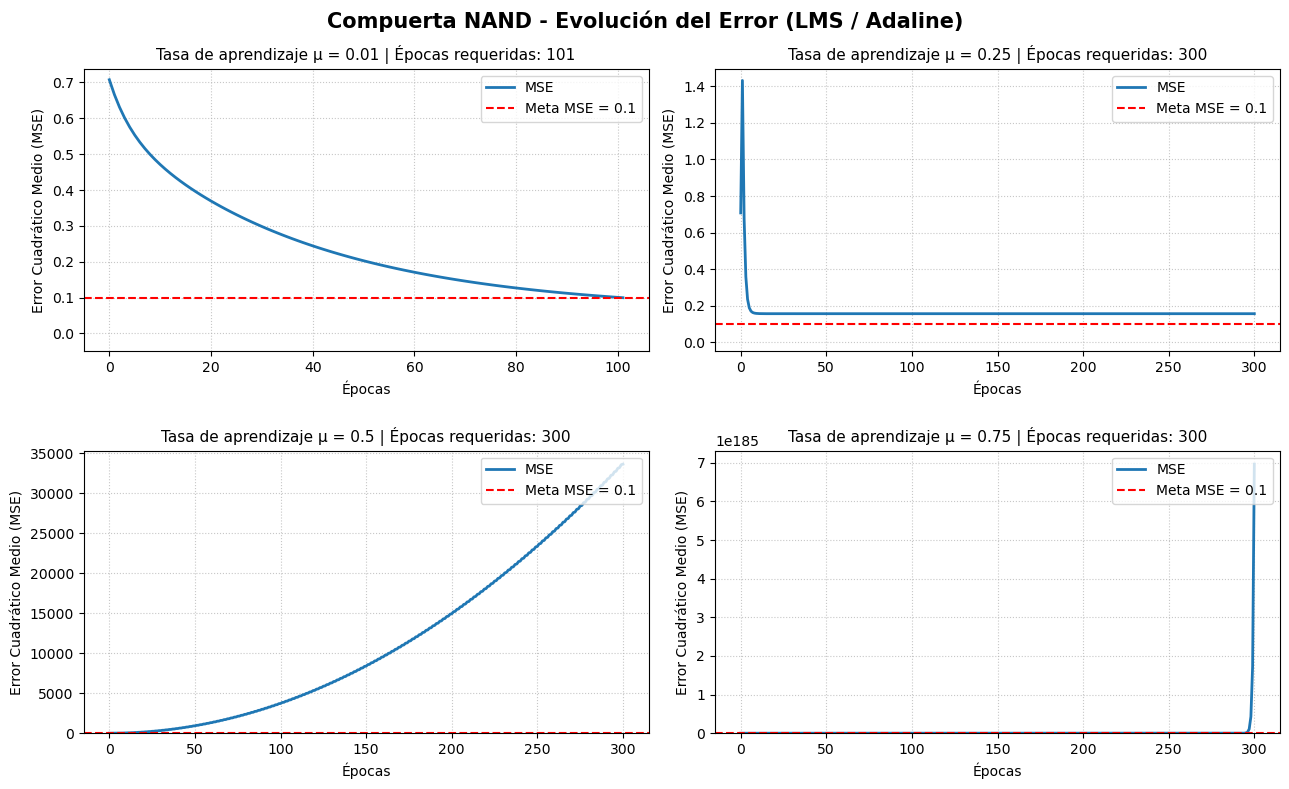

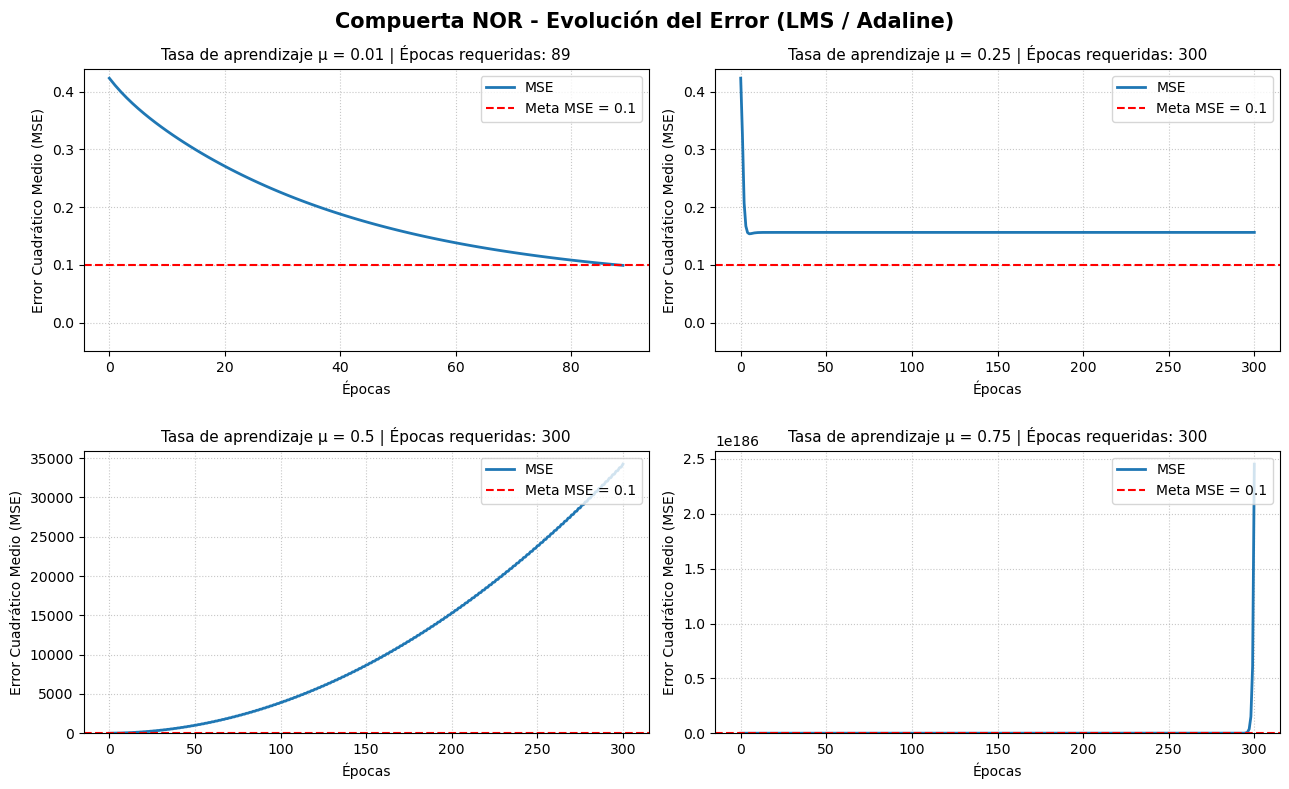

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Matriz de Entradas X [x0, x1, x2] con bias x0 = 1
X = np.array([[1, 0, 0], [1, 0, 1], [1, 1, 0], [1, 1, 1]])

# 2. Salidas deseadas 'd' para las compuertas linealmente separables
gates = {
    'AND': np.array([0, 0, 0, 1]),
    'OR': np.array([0, 1, 1, 1]),
    'NAND': np.array([1, 1, 1, 0]),
    'NOR': np.array([1, 0, 0, 0]),
}

mus = [0.01, 0.25, 0.50, 0.75]
target_xi = 0.1  # Criterio de parada: xi_p <= 0.1
max_epochs = 300

# Vector de pesos iniciales aleatorios [w0, w1, w2] compartido para todas las pruebas
np.random.seed(42)
initial_weights = np.random.uniform(-0.5, 0.5, size=3)

# 3. Iteración por compuerta creando una figura con 4 subgráficas (una por cada Mu)
for gate_name, d in gates.items():
  fig, axes = plt.subplots(2, 2, figsize=(12, 8))
  fig.suptitle(
      f'Compuerta {gate_name} - Evolución de $\\xi_p$ para cada valor de $\\mu$',
      fontsize=14,
      fontweight='bold',
  )

  # Aplanar la matriz de ejes para iterar fácilmente del 0 al 3
  axes_flat = axes.flatten()

  for i, mu in enumerate(mus):
    w = initial_weights.copy()
    xi_history = []
    epoch = 0

    # Error promedio inicial (xi_p)
    y_init = np.dot(X, w)
    e_init = d - y_init
    xi_p = np.mean(e_init**2)
    xi_history.append(xi_p)

    # Entrenamiento mediante el ciclo 'while' solicitado
    while xi_p > target_xi and epoch < max_epochs:
      # Actualización LMS patrón por patrón
      for k in range(len(X)):
        x_k = X[k]
        d_k = d[k]
        y_k = np.dot(w, x_k)
        e_k = d_k - y_k

        # Regla del paso más descendente: w = w + 2 * mu * e_k * x_k
        w = w + 2 * mu * e_k * x_k

      # Cálculo del error promedio al finalizar la época
      y_epoch = np.dot(X, w)
      e_epoch = d - y_epoch
      xi_p = np.mean(e_epoch**2)
      xi_history.append(xi_p)
      epoch += 1

    # Graficar en la subgráfica individual para este Mu
    ax = axes_flat[i]
    ax.plot(
        range(len(xi_history)),
        xi_history,
        color='#1f77b4',
        linewidth=1.8,
        label=f'$\\xi_p$ (Épocas: {epoch})',
    )
    ax.axhline(
        y=target_xi,
        color='r',
        linestyle='--',
        alpha=0.7,
        label=f'Meta $\\xi_p = {target_xi}$',
    )

    ax.set_title(f'Tasa de aprendizaje $\\mu = {mu}$', fontsize=11)
    ax.set_xlabel('epoch')
    ax.set_ylabel('$\\xi_p$')
    ax.set_ylim(bottom=-0.02)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right')

  plt.tight_layout()
  plt.show()